In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
playstore_df = pd.read_csv('Play_Store_2.csv') 

In [7]:
playstore_df.head()

,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice
0,War Dragons,Others,3.9,160604.0,270.0,10000000.0,Free,0.0,Everyone,Yes,Yes,Yes
1,CV-Library Job Search,BUSINESS,4.4,NaN,46.0,100000.0,Free,0.0,Everyone,No,No,No
2,Surah Al-Waqiah,BOOKS_AND_REFERENCE,NaN,1201.0,29.0,100000.0,Free,0.0,Everyone,Yes,No,No
3,Ay,Others,NaN,11.0,36.0,5000.0,Free,0.0,Teen,Yes,No,No
4,EA Plus,Others,2.5,12.0,12.0,1000.0,Free,0.0,Everyone,No,No,No


In [8]:
playstore_df.shape

(4153, 12)

In [12]:
playstore_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,3976.0,4.189487e+00,5.197921e-01,1.000,4.0,4.3,4.5,5.00
Reviews,4029.0,6.696421e+04,1.074189e+05,1.000,224.0,7461.0,78219.0,312204.00
Size,4153.0,8.225441e+01,9.225633e+01,0.011,22.0,42.0,84.0,270.00
Installs,4153.0,3.232706e+06,5.421343e+06,1.000,10000.0,500000.0,5000000.0,19970000.00
Price,4153.0,5.653407e-01,8.926313e+00,0.000,0.0,0.0,0.0,399.99


In [13]:
playstore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4153 entries, 0 to 4152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   App               4153 non-null   object 
 1   Category          4153 non-null   object 
 2   Rating            3976 non-null   float64
 3   Reviews           4029 non-null   float64
 4   Size              4153 non-null   float64
 5   Installs          4153 non-null   float64
 6   Paid/Free         4153 non-null   object 
 7   Price             4153 non-null   float64
 8   Content Rating    4153 non-null   object 
 9   Ad Supported      4153 non-null   object 
 10  In App Purchases  4153 non-null   object 
 11  Editors Choice    4153 non-null   object 
dtypes: float64(5), object(7)
memory usage: 389.5+ KB


In [14]:
playstore_df.isna().sum()

App                   0
Category              0
Rating              177
Reviews             124
Size                  0
Installs              0
Paid/Free             0
Price                 0
Content Rating        0
Ad Supported          0
In App Purchases      0
Editors Choice        0
dtype: int64

In [62]:
playstore_df['Ad Supported'].value_counts()

Ad Supported
Yes    2208
No     1945
Name: count, dtype: int64

### Filtering out the Apps that do not support Ads

In [70]:
ad_supported_apps = playstore_df[playstore_df['Ad Supported'] == 'Yes'].copy()

In [280]:
ad_supported_apps['Content Rating'].value_counts(normalize=True)

Content Rating
Everyone        0.735054
Teen            0.154891
Everyone 10+    0.068841
Mature 17+      0.041214
Name: proportion, dtype: float64

### 'EVERYONE' constitues ~74% of the total Content Rating, followed by 'TEEN'

In [279]:
ad_supported_apps['Category'].value_counts(normalize=True)

Category
Others                 0.346014
FAMILY                 0.191576
GAME                   0.158967
TOOLS                  0.057518
SPORTS                 0.043478
PHOTOGRAPHY            0.033062
HEALTH_AND_FITNESS     0.028533
PERSONALIZATION        0.028080
LIFESTYLE              0.023551
BOOKS_AND_REFERENCE    0.019928
FINANCE                0.017210
PRODUCTIVITY           0.015399
COMMUNICATION          0.015399
MEDICAL                0.011322
BUSINESS               0.009964
Name: proportion, dtype: float64

### 'OTHERS' constitute ~34% of the total categories, followed by FAMILY and GAME

In [131]:
ad_supported_apps['Reviews'].isna().sum()/ad_supported_apps.shape[0] 

np.float64(0.028532608695652172)

### Only 2% of the apps have no Reviews

In [116]:
ad_supported_apps.groupby('Category')['log_installs'].median().nlargest(5)

Category
GAME             6.69897
PHOTOGRAPHY      6.69897
SPORTS           6.69897
BUSINESS         6.00000
COMMUNICATION    6.00000
Name: log_installs, dtype: float64

In [119]:
ad_supported_apps.groupby(['Category', 'Content Rating'])['log_installs'].median().nlargest(5)

Category             Content Rating
TOOLS                Teen              7.300378
PHOTOGRAPHY          Mature 17+        7.150189
BOOKS_AND_REFERENCE  Teen              7.000000
GAME                 Everyone 10+      7.000000
                     Mature 17+        7.000000
Name: log_installs, dtype: float64

### Creating engagement_rate to support further analysis

In [125]:
ad_supported_apps['engagement_rate'] = ad_supported_apps['Reviews'].fillna(0)/ad_supported_apps['Installs']


In [127]:
ad_supported_apps['engagement_rate'].quantile(0.50)

np.float64(0.0164)

In [284]:
# Transforming Installs to support analysis

ad_supported_apps['log_installs'] = np.log10(ad_supported_apps['Installs'])

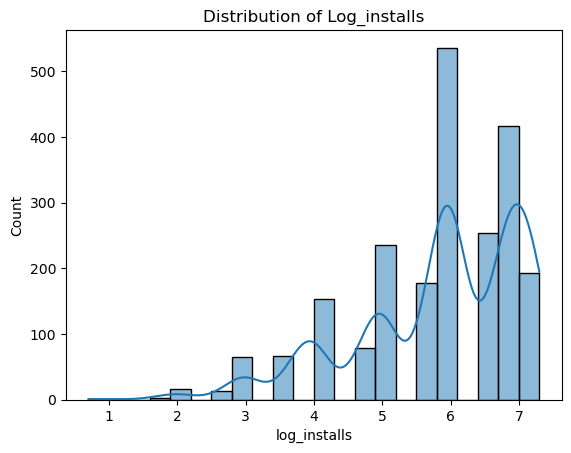

In [453]:
sns.histplot(data=ad_supported_apps, x='log_installs', kde=True)
plt.title('Distribution of Log_installs');

1. Most apps sit in the higher install ranges (1M - 10M)
2. The dips in the KDE indicate a platform imposed curve
3. The peaks are user-install brackets

In [146]:
cat_median = ad_supported_apps.groupby('Category')['Rating'].median()

### Imputing missing rating with Median Rating wrt Category

In [152]:
ad_supported_apps['Rating'] = ad_supported_apps['Rating'].fillna(ad_supported_apps['Category'].map(cat_median))

In [153]:
ad_supported_apps['Rating'].isna().sum()

np.int64(0)

### defining 'score' to filter of categories with a good balance of reach and interaction

In [310]:
ad_supported_apps['score'] = (ad_supported_apps['engagement_rate']*ad_supported_apps['log_installs'])

In [311]:
ad_supported_apps.head()


,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice,log_installs,engagement_rate,app_quality,score
0,War Dragons,Others,3.9,160604.0,270.0,10000000.0,Free,0.0,Everyone,Yes,Yes,Yes,7.00000,0.016060,Poor,0.112423
2,Surah Al-Waqiah,BOOKS_AND_REFERENCE,4.4,1201.0,29.0,100000.0,Free,0.0,Everyone,Yes,No,No,5.00000,0.012010,Poor,0.060050
3,Ay,Others,4.3,11.0,36.0,5000.0,Free,0.0,Teen,Yes,No,No,3.69897,0.002200,Poor,0.008138
6,SAMURAI vs ZOMBIES DEFENSE,GAME,4.5,312204.0,19.0,5000000.0,Free,0.0,Everyone,Yes,Yes,No,6.69897,0.062441,Premium,0.418289
8,Draw In,GAME,4.2,46416.0,73.0,10000000.0,Free,0.0,Everyone,Yes,Yes,No,7.00000,0.004642,Poor,0.032491


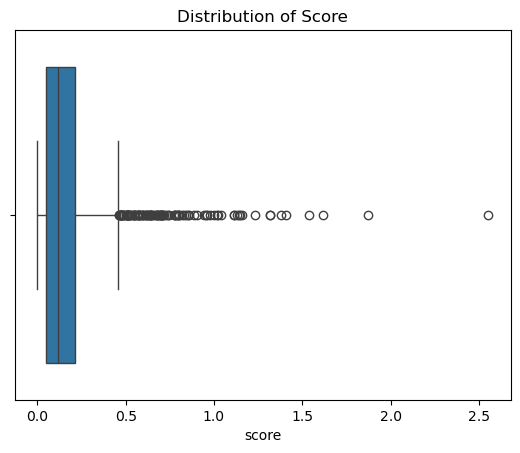

In [452]:
sns.boxplot(data=ad_supported_apps, x='score')
plt.title('Distribution of Score');

In [314]:
ad_supported_apps['score'].describe()

count    2208.000000
mean        0.157839
std         0.183122
min         0.000000
25%         0.050688
50%         0.114132
75%         0.214390
max         2.553400
Name: score, dtype: float64

In [318]:
ad_supported_apps.groupby('Category')['score'].median().reset_index().sort_values('score', ascending=False)

,Category,score
4,FINANCE,0.123628
9,Others,0.117507
5,GAME,0.114132
13,SPORTS,0.114132
2,COMMUNICATION,0.110380
6,HEALTH_AND_FITNESS,0.103904
12,PRODUCTIVITY,0.092916
3,FAMILY,0.091855
11,PHOTOGRAPHY,0.090490
10,PERSONALIZATION,0.079042


### Finance with a score of 0.12 indicates that it has a good balance of reach and user interaction

In [394]:
# score_tier:
# Combines performance (score), user satisfaction (rating), 
# and scale (installs) to classify apps into Elite, High, Mid, Low tiers

# Score thresholds:
# q25, q75, q90 → define performance tiers

# Rating thresholds:
# r50, r75, r90 → increasing quality requirements

# Install thresholds:
# i25, i50 → ensure minimum scale for higher tiers

q25 = ad_supported_apps['score'].quantile(0.25)
q75 = ad_supported_apps['score'].quantile(0.75)
q90 = ad_supported_apps['score'].quantile(0.90)

r50 = ad_supported_apps['Rating'].quantile(0.5) # Baseline Rating
r75 = ad_supported_apps['Rating'].quantile(0.75)
r90 = ad_supported_apps['Rating'].quantile(0.90)

i25 = ad_supported_apps['Installs'].quantile(0.25)
i50 = ad_supported_apps['Installs'].quantile(0.50)


In [395]:
# Logic:
# Higher tiers require stricter conditions:
# - Elite: high score + top rating + strong installs
# - High: good score + good rating + moderate installs
# - Mid: average score + baseline rating
# - Low: everything else



choices = ['Elite', 'High', 'Mid'] 

conditions = [
    (ad_supported_apps['score'] >= q90) & (ad_supported_apps['Rating'] >= r90) & (ad_supported_apps['Installs'] >= i50),
    (ad_supported_apps['score'] >= q75) & (ad_supported_apps['Rating'] >= r75) & (ad_supported_apps['Installs'] >= i25),
    (ad_supported_apps['score'] >= q25) & (ad_supported_apps['Rating'] >= r50)
]

ad_supported_apps['score_tier'] = np.select(
    conditions,
    choices,
    default = 'Low'
)

In [325]:
ad_supported_apps.head()

,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice,log_installs,engagement_rate,app_quality,score,score_tier
0,War Dragons,Others,3.9,160604.0,270.0,10000000.0,Free,0.0,Everyone,Yes,Yes,Yes,7.00000,0.016060,Poor,0.112423,Low
2,Surah Al-Waqiah,BOOKS_AND_REFERENCE,4.4,1201.0,29.0,100000.0,Free,0.0,Everyone,Yes,No,No,5.00000,0.012010,Poor,0.060050,Mid
3,Ay,Others,4.3,11.0,36.0,5000.0,Free,0.0,Teen,Yes,No,No,3.69897,0.002200,Poor,0.008138,Low
6,SAMURAI vs ZOMBIES DEFENSE,GAME,4.5,312204.0,19.0,5000000.0,Free,0.0,Everyone,Yes,Yes,No,6.69897,0.062441,Premium,0.418289,High
8,Draw In,GAME,4.2,46416.0,73.0,10000000.0,Free,0.0,Everyone,Yes,Yes,No,7.00000,0.004642,Poor,0.032491,Low


In [358]:
ad_supported_apps['score_tier'].value_counts()

score_tier
Low      1139
Mid       838
High      186
Elite      45
Name: count, dtype: int64

### Elite tier has 45 apps, lets find out which categories constitute this category

In [368]:
category_tier = pd.crosstab(ad_supported_apps['Category'], ad_supported_apps['score_tier'])

In [360]:
category_tier

score_tier,Elite,High,Low,Mid
Category,,,,
BOOKS_AND_REFERENCE,1,3,24,16
BUSINESS,0,2,11,9
COMMUNICATION,0,1,25,8
FAMILY,8,29,252,134
FINANCE,0,6,14,18
GAME,5,33,153,160
HEALTH_AND_FITNESS,1,11,18,33
LIFESTYLE,1,5,27,19
MEDICAL,2,0,16,7


In [375]:
ad_supported_apps[ad_supported_apps['score_tier'].isin(['Elite', 'High', 'Mid'])].groupby('Category')['Installs'].sum().reset_index().sort_values('Installs', ascending=False)

,Category,Installs
9,Others,2.467465e+09
5,GAME,1.675965e+09
3,FAMILY,4.982670e+08
14,TOOLS,2.728110e+08
13,SPORTS,2.708110e+08
11,PHOTOGRAPHY,2.688300e+08
6,HEALTH_AND_FITNESS,1.929700e+08
7,LIFESTYLE,1.220670e+08
2,COMMUNICATION,9.541500e+07
10,PERSONALIZATION,8.122505e+07


1. 'Others' is the Reach Giant the with most number of Total Installs - Need to drill down further to see what this Category captures
2. GAMES is the next quality Contender for Total reach. 

In [381]:
ad_supported_apps.loc[(ad_supported_apps['Category'] == 'Others') & (ad_supported_apps['score_tier'].isin(choices)), 'Size'].value_counts(normalize=True)

Size
270.000    0.698765
18.000     0.014815
11.000     0.012346
24.000     0.009877
87.000     0.009877
             ...   
0.847      0.002469
32.000     0.002469
75.000     0.002469
48.000     0.002469
41.000     0.002469
Name: proportion, Length: 61, dtype: float64

### ~70% of apps from 'Others' category with the score_tier excluding low have a size of 270MB which are mostly High simulation games that was marked as 'Others'

In [382]:
ad_supported_apps.loc[(ad_supported_apps['Category'] == 'GAME') & (ad_supported_apps['score_tier'].isin(choices)), 'Size'].value_counts(normalize=True)

Size
99.0     0.040404
59.0     0.030303
63.0     0.030303
24.0     0.030303
96.0     0.025253
           ...   
100.0    0.005051
44.0     0.005051
97.0     0.005051
67.0     0.005051
27.0     0.005051
Name: proportion, Length: 81, dtype: float64

In [384]:
ad_supported_apps.loc[(ad_supported_apps['Category'] == 'SPORTS') & (ad_supported_apps['score_tier'].isin(choices)), 'Size'].value_counts(normalize=True)

Size
270.0    0.428571
73.0     0.047619
14.0     0.047619
40.0     0.047619
41.0     0.023810
51.0     0.023810
98.0     0.023810
34.0     0.023810
58.0     0.023810
21.0     0.023810
19.0     0.023810
65.0     0.023810
11.0     0.023810
47.0     0.023810
30.0     0.023810
28.0     0.023810
87.0     0.023810
12.0     0.023810
26.0     0.023810
45.0     0.023810
81.0     0.023810
35.0     0.023810
Name: proportion, dtype: float64

### 42% of Apps from Sports Category are of size 270 MB size, which indicates the presence of 'High end Apps',

### Segmenting by score tier

In [403]:
elite_tier = ad_supported_apps[ad_supported_apps['score_tier'] == 'Elite'].copy()

In [402]:
high_tier = ad_supported_apps[ad_supported_apps['score_tier'] == 'High'].copy()

In [401]:
mid_tier = ad_supported_apps[ad_supported_apps['score_tier'] == 'Mid'].copy()

### Checking the distribution of IAP across Tiers

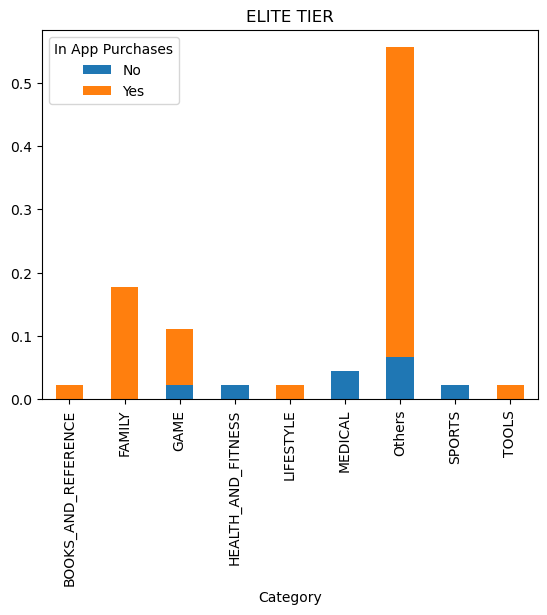

In [451]:
pd.crosstab(elite_tier['Category'], elite_tier['In App Purchases'], normalize=True).plot(kind='bar', stacked=True);
plt.title('ELITE TIER');

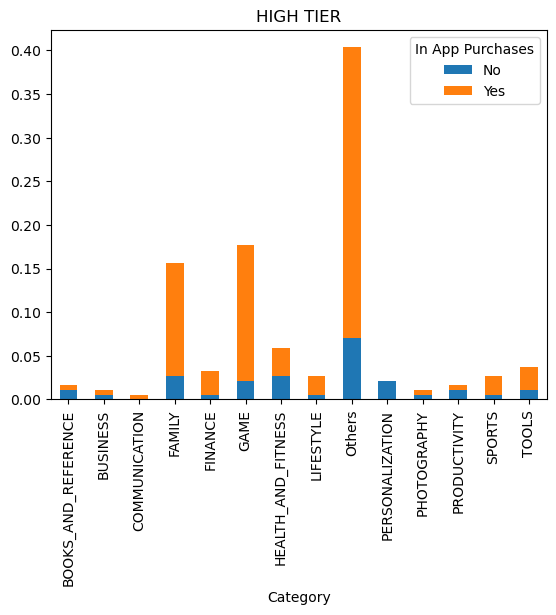

In [450]:
pd.crosstab(high_tier['Category'], high_tier['In App Purchases'], normalize=True).plot(kind='bar', stacked=True);
plt.title('HIGH TIER');

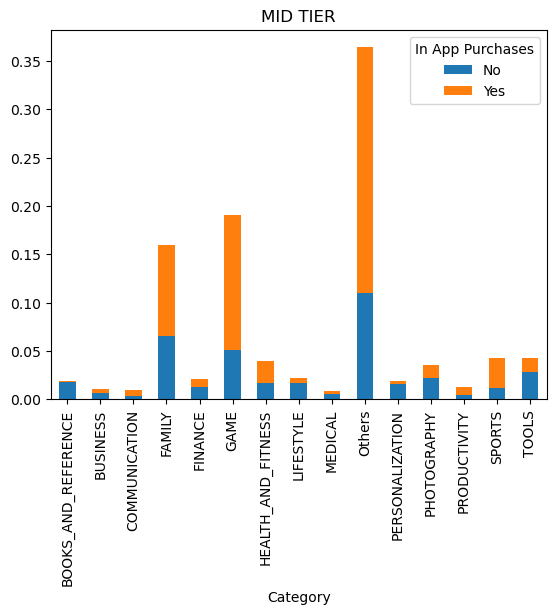

In [448]:
pd.crosstab(mid_tier['Category'], mid_tier['In App Purchases'], normalize=True).plot(kind='bar', stacked=True);
plt.title('MID TIER');

1. Elite-tier apps are predominantly IAP-enabled, especially in categories like Family and Games, indicating that top-performing apps tend to adopt hybrid monetization strategies.
2. High-tier apps continue to show a strong preference for hybrid monetization, particularly in Games and Family categories, suggesting that combining ads with in-app purchases is a common strategy among well-performing apps.
3. Mid-tier apps provide the largest inventory of ad-supported apps, with a mix of ad-only and hybrid models. While IAP-enabled apps still dominate, the presence of ad-only apps is higher compared to top tiers, indicating greater diversity in monetization strategies.

In [405]:
elite_tier.head()

,App,Category,Rating,Reviews,Size,Installs,Paid/Free,Price,Content Rating,Ad Supported,In App Purchases,Editors Choice,log_installs,engagement_rate,score,score_tier
46,"Underworld Office: Visual Novel, Adventure Game",Others,4.7,105798.0,270.0,1000000.0,Free,0.0,Teen,Yes,Yes,Yes,6.00000,0.105798,0.634788,Elite
181,"Egg, Inc.",FAMILY,4.7,312204.0,29.0,5000000.0,Free,0.0,Everyone,Yes,Yes,Yes,6.69897,0.062441,0.418289,Elite
310,Animal Restaurant,Others,4.7,312204.0,270.0,5000000.0,Free,0.0,Everyone,Yes,Yes,Yes,6.69897,0.062441,0.418289,Elite
383,Drag'n'Boom,GAME,4.8,133180.0,54.0,1000000.0,Free,0.0,Everyone 10+,Yes,Yes,Yes,6.00000,0.133180,0.799080,Elite
395,PixPanda - Color by Number Pixel Art Coloring ...,FAMILY,4.9,55723.0,14.0,1000000.0,Free,0.0,Everyone,Yes,Yes,No,6.00000,0.055723,0.334338,Elite


### Checking the distribution of Editors Choice apps across Tiers

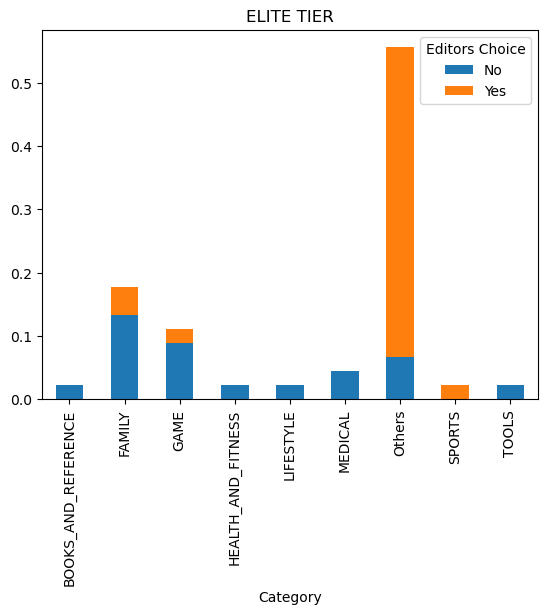

In [447]:
pd.crosstab(elite_tier['Category'], elite_tier['Editors Choice'], normalize=True).plot(kind='bar', stacked=True)
plt.title('ELITE TIER');

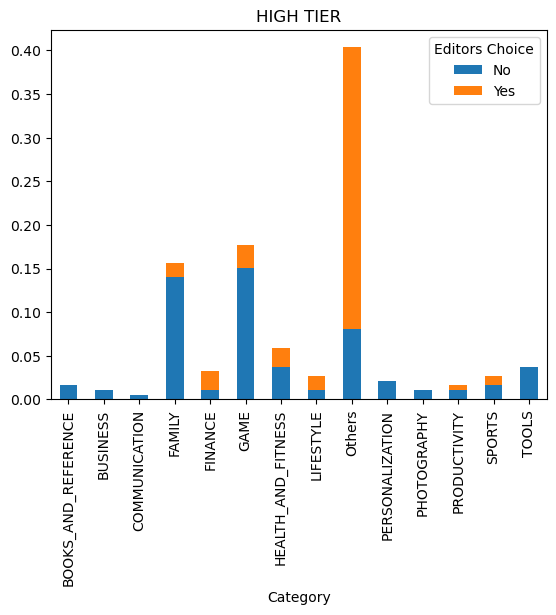

In [446]:
pd.crosstab(high_tier['Category'], high_tier['Editors Choice'], normalize=True).plot(kind='bar', stacked=True)
plt.title('HIGH TIER');

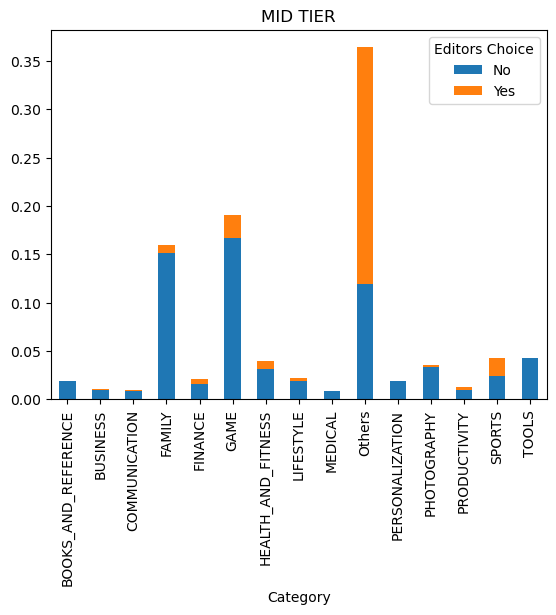

In [445]:
pd.crosstab(mid_tier['Category'], mid_tier['Editors Choice'], normalize=True).plot(kind='bar', stacked=True)
plt.title('MID TIER');

While mid-tier apps contribute the largest volume of Editors’ Choice apps, higher tiers are expected to have a greater concentration of such apps, indicating stronger quality signals among top-performing segments.

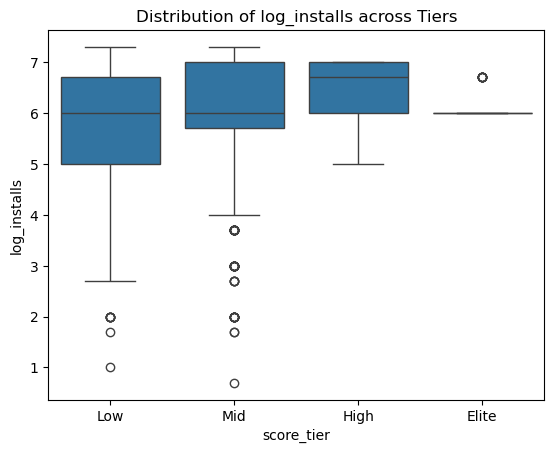

In [443]:
sns.boxplot(data=ad_supported_apps, x='score_tier', y='log_installs');
plt.title('Distribution of log_installs across Tiers');

Text(0.5, 1.0, 'Typical Installs Across Tiers')

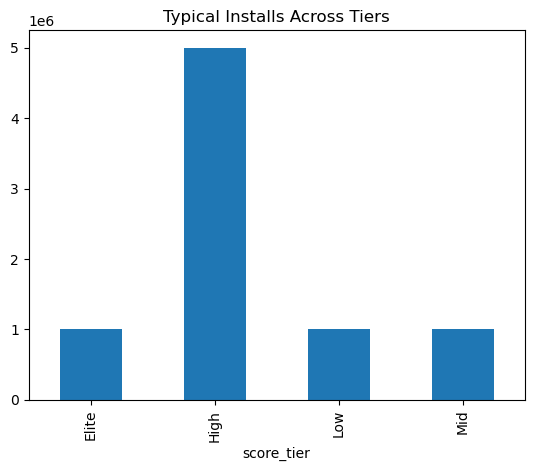

In [441]:
ad_supported_apps.groupby('score_tier')['Installs'].median().plot(kind='bar');
plt.title('Typical Installs Across Tiers');

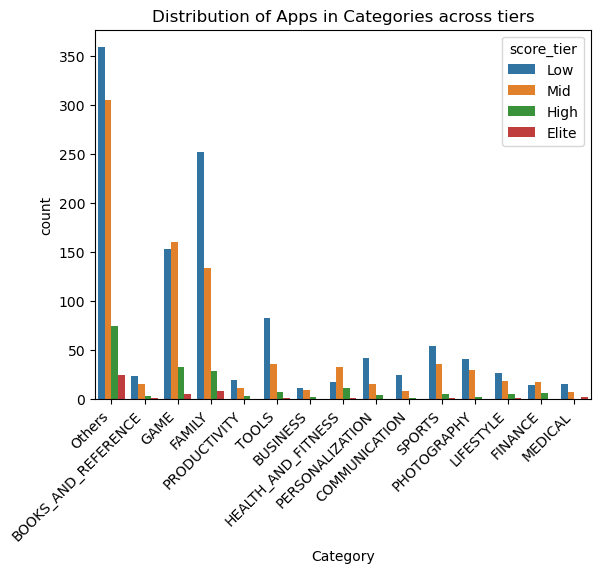

In [440]:
sns.countplot(data=ad_supported_apps, x='Category', hue='score_tier')
plt.xticks(rotation=45, ha='right');
plt.title('Distribution of Apps in Categories across tiers');

### Across all categories, the majority of apps fall into the Low and Mid tiers, with High and Elite tiers representing a significantly smaller portion, indicating that high-quality, high-performing apps are relatively scarce.

### Distribution of Content Rating across Categories

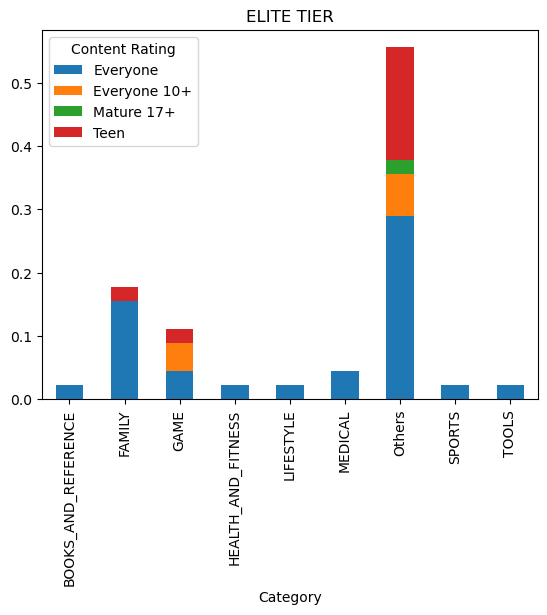

In [434]:
pd.crosstab(elite_tier['Category'], elite_tier['Content Rating'], normalize=True).plot(kind='bar', stacked=True)
plt.title('ELITE TIER');

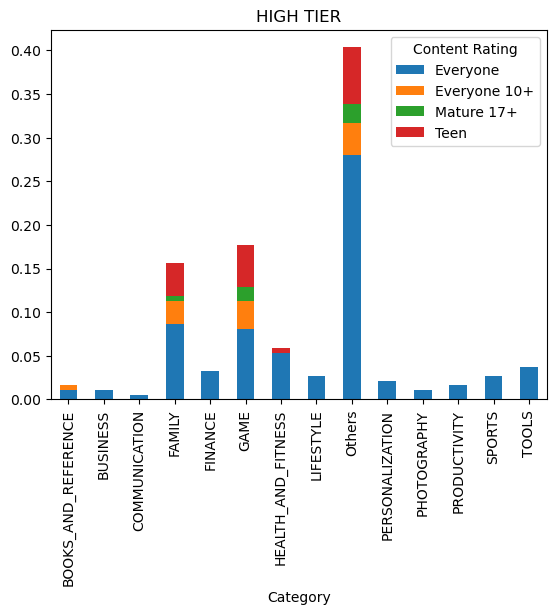

In [435]:
pd.crosstab(high_tier['Category'], high_tier['Content Rating'], normalize=True).plot(kind='bar', stacked=True)
plt.title('HIGH TIER');

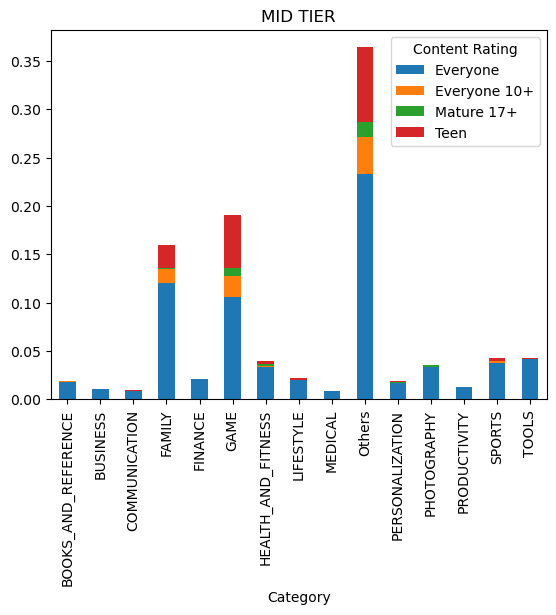

In [437]:
pd.crosstab(mid_tier['Category'], mid_tier['Content Rating'], normalize=True).plot(kind='bar', stacked=True)
plt.title('MID TIER');

## Business Summary
#### Objective

The objective of this analysis was to help Zoom Ads identify high-value advertising opportunities within the Google Play Store ecosystem by understanding app performance, user engagement, and monetization patterns.

#### Approach

A data-driven framework was developed to evaluate apps across three key dimensions:

1. Scale (number of installs)
2. User Engagement (reviews relative to installs)
3. User Satisfaction (ratings)

A composite score was constructed using these metrics, and apps were segmented into four tiers: Elite, High, Mid, and Low. This segmentation enabled a structured view of the app marketplace and supported targeted decision-making for advertising strategies.

#### Key Findings
1. ##### Market Structure:
    The majority of apps fall within the Low and Mid tiers, while High and Elite apps are relatively scarce. This indicates that high-performing apps represent a limited but valuable segment of the market.
2. ##### Mid-tier as a Scale Opportunity:
    Mid-tier apps form the largest share of the dataset and offer a diverse mix of monetization models. These apps are well-suited for campaigns focused on reach and cost efficiency.
3. ##### Elite and High tiers as Premium Inventory:
    Apps in the Elite and High tiers demonstrate a strong combination of scale, engagement, and user satisfaction. These apps can be positioned as premium advertising placements due to their combination of high reach and user interaction.
4. ##### Monetization Patterns:
    Top-performing apps predominantly adopt hybrid monetization strategies, combining advertisements with in-app purchases. In contrast, mid-tier apps show a higher presence of ad-only models, indicating greater diversity in monetization approaches.
5. ##### Category-Level Insights:
    Categories such as Games and Family show stronger representation in higher tiers and consistently adopt in-app purchase models. These categories indicate a more mature and engagement-driven ecosystem, making them attractive targets for advertising campaigns.
6. ##### Editors’ Choice Distribution:
    Editors’ Choice apps are distributed across all tiers, with mid-tier contributing a higher absolute number due to its larger size. However, editorial recognition is not exclusive to top-tier apps and should be considered as a supporting quality signal rather than a primary decision factor.


#### Business Recommendations

A tiered advertising strategy is recommended:

Elite Tier: Premium placements for high-impact campaigns, leveraging strong engagement and scale
High Tier: Balanced option for performance-driven campaigns
Mid Tier: Scalable inventory for reach-oriented and cost-efficient campaigns

This structured approach allows Zoom Ads to align campaign objectives with appropriate app segments, optimizing both reach and performance outcomes.

#### Conclusion

The Google Play Store ecosystem is characterized by a large base of mid-performing apps and a limited set of high-performing apps. By leveraging a tiered segmentation strategy, Zoom Ads can effectively balance premium advertising opportunities with scalable reach, enabling more efficient and targeted campaign execution.